In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import tensorflow_probability.substrates.jax.bijectors as tfb

# Walk up from cwd until we find pyproject.toml — Jupyter sets cwd to the
# notebook folder, so we cannot assume the repo root is cwd.
project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.analysis import (
    summarize_mu,
    plot_mu_diagnostics,
    plot_cholesky_trace,
    recover_covariance_matrix,
    plot_final_covariance_complete,
    plot_goose_style_diagnostics,
    generate_delta_summaries,
    plot_delta_distributions,
    plot_beta_scatter,
    plot_beta_distributions,
    plot_beta_unit_diagnostics,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 9)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Load Posterior Draws ──────────
# Layout: liesel.ipynb lives in <run>/ - all artifacts live in <run>/results/

def _resolve_run_dir():
    # VS Code injects __vsc_ipynb_file__ with the notebook's absolute path.
    # Falling back to cwd works when running outside VS Code.
    nb = globals().get("__vsc_ipynb_file__")
    if nb:
        return pathlib.Path(nb).resolve().parent
    return pathlib.Path.cwd()

RUN_DIR     = _resolve_run_dir()
RESULTS_DIR = RUN_DIR / "results"

meta_path = RESULTS_DIR / "meta.json"

if not meta_path.exists():
    raise FileNotFoundError(
        f"meta.json not found in:\n  {RESULTS_DIR}\n\n"
        f"This notebook must live in a run folder produced by run_single_experiment.py,\n"
        f"with artifacts in a results/ subfolder.\n"
        f"If you are in VS Code and this fails, set the setting\n"
        f"  \"jupyter.notebookFileRoot\": \"${{fileDirname}}\"\n"
        f"so the working directory is the notebook's own folder, then restart the kernel."
    )

with open(meta_path) as f:
    meta = json.load(f)

SCENARIO_NAME = meta["scenario"]
K_MODEL       = int(meta["k_model"])   # components the model was fitted with
K_TRUE        = int(meta["k_true"])    # components in the DGP (may differ from K_MODEL)
SAMPLER       = meta["sampler"]
CHAINS        = int(meta["chains"])

with open(RESULTS_DIR / "posterior_raw.pkl", "rb") as f:
    posterior_samples = pickle.load(f)

print(f"Run folder  : {RUN_DIR}")
print(f"Results dir : {RESULTS_DIR}")
print(f"Scenario    : {SCENARIO_NAME}   sampler: {SAMPLER}   chains: {CHAINS}")
print(f"K_MODEL     : {K_MODEL}   K_TRUE : {K_TRUE}")
print(f"warmup/post : {meta.get('warmup')} / {meta.get('posterior')}   "
      f"duration: {meta.get('duration_s')} s")
print("\nPosterior arrays:")
for key, val in posterior_samples.items():
    print(f"   {key:<28} {np.asarray(val).shape}")

Run folder  : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_normal_experiments\HMC\standard_seed42
Results dir : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_normal_experiments\HMC\standard_seed42\results
Scenario    : standard   sampler: hmc   chains: 2
K_MODEL     : 1   K_TRUE : 1
warmup/post : 2000 / 10000   duration: 309.6 s

Posterior arrays:
   Delta                        (2, 10000, 2, 4)
   beta_i                       (2, 10000, 300, 4)
   mu                           (2, 10000, 4)
   sigma_inv_chol_latent        (2, 10000, 10)


In [3]:
# ── Cell 3 : Load Ground Truth ──────────
# Ground truth is not stored in the posterior pickle - it lives in the data JSON.

data_path = project_root / "data" / "simulated" / "mixture" / f"{SCENARIO_NAME}.json"
with open(data_path) as f:
    raw_data = json.load(f)

P       = int(raw_data["n_params"])
D       = int(raw_data.get("n_demos", 0))
n_units = int(raw_data["n_units"])

# Returns None when a key is absent so callers can guard with `if t_x is not None`.
def _arr(key):
    return np.array(raw_data[key]) if raw_data.get(key) is not None else None

t_sigma = _arr("TRUE_SIGMA")   # (P, P)
t_delta = _arr("TRUE_DELTA")   # (D, P)
t_beta  = _arr("TRUE_BETA")    # (N, P)
t_mu    = _arr("TRUE_MU")      # (P,)

param_names = raw_data.get("param_names") or [f"Param_{i}" for i in range(P)]
demo_names  = raw_data.get("demo_names")  or [f"Demo_{i}"  for i in range(D)]

print(f"Ground truth loaded from {data_path.name}  (P={P}, D={D}, N={n_units})")
print(f"param_names : {param_names}")
print(f"demo_names  : {demo_names}")

Ground truth loaded from standard.json  (P=4, D=2, N=300)


param_names : ['Alt1', 'Alt2', 'Alt3', 'Price']
demo_names  : ['z1', 'z2']



=== mu: Posterior Summary ===


,True_Value,Posterior_Mean,Posterior_Std,Diff_Abs
Parameter,,,,
Alt1,0.7570,0.7909,0.0729,0.0339
Alt2,-0.9222,-0.8986,0.0985,0.0235
Alt3,0.8696,0.9428,0.0800,0.0732
Price,1.3556,1.4377,0.0717,0.0821


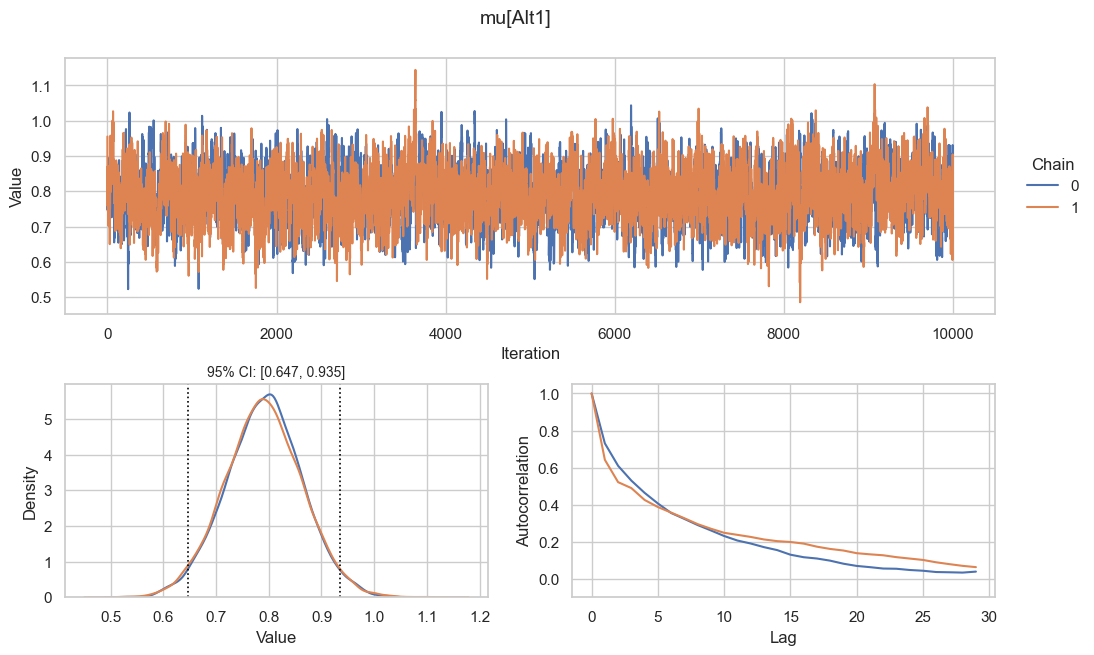

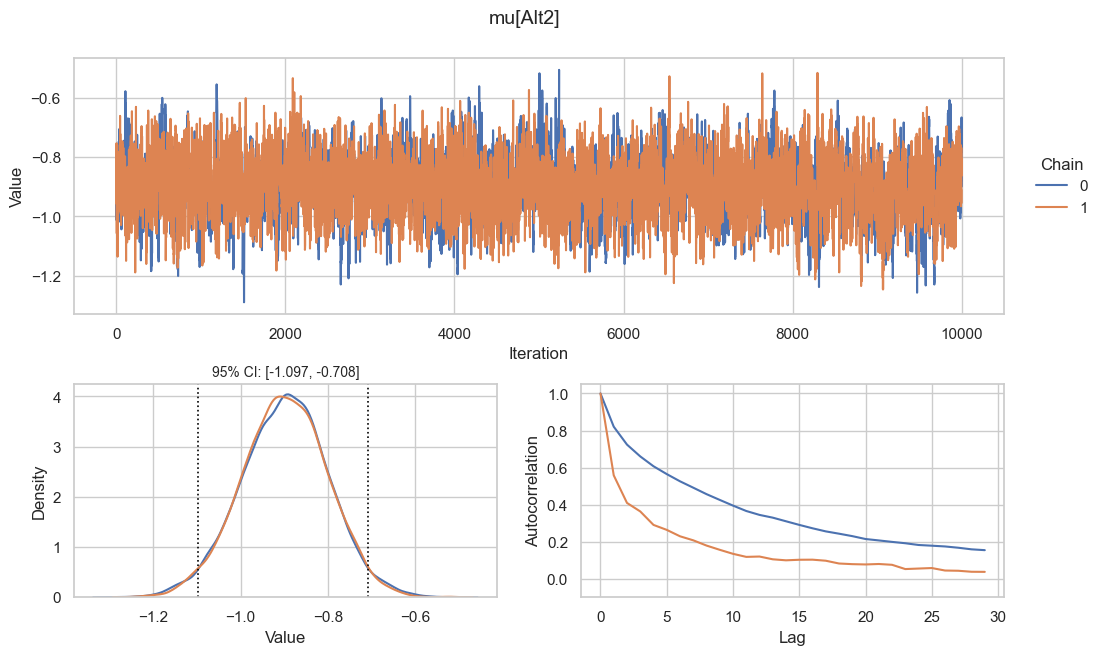

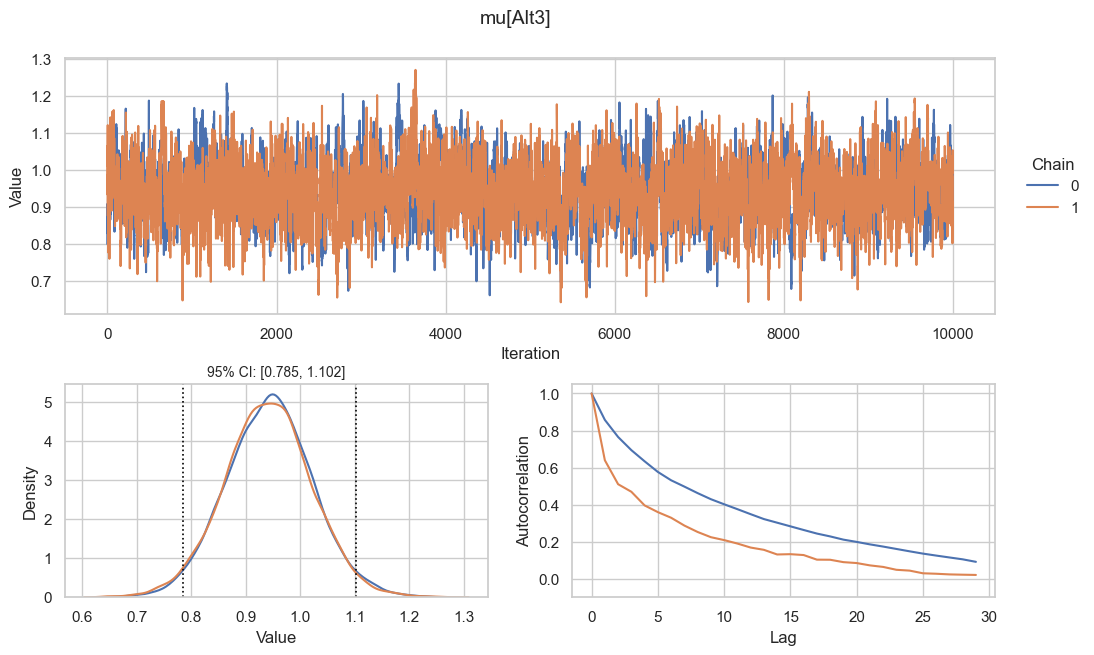

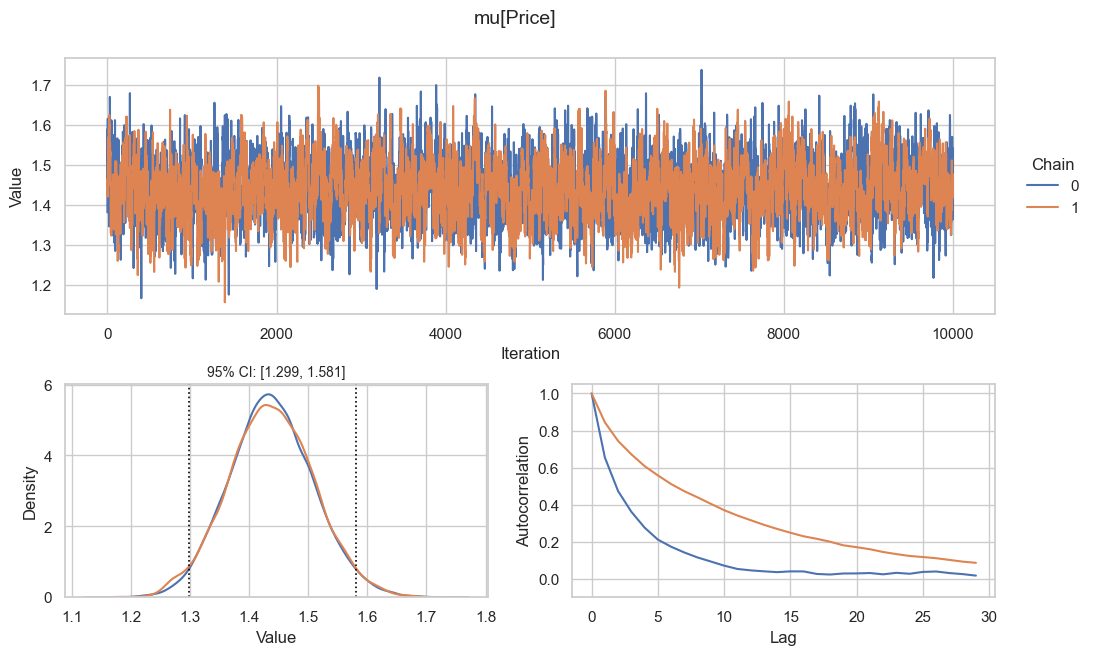

In [4]:
# ── Cell 4 : Population Mean (mu) ──────────
samples = posterior_samples

summarize_mu(samples["mu"], P=P, param_names=param_names, true_mu=t_mu)

plot_mu_diagnostics(samples["mu"], P=P, param_names=param_names)

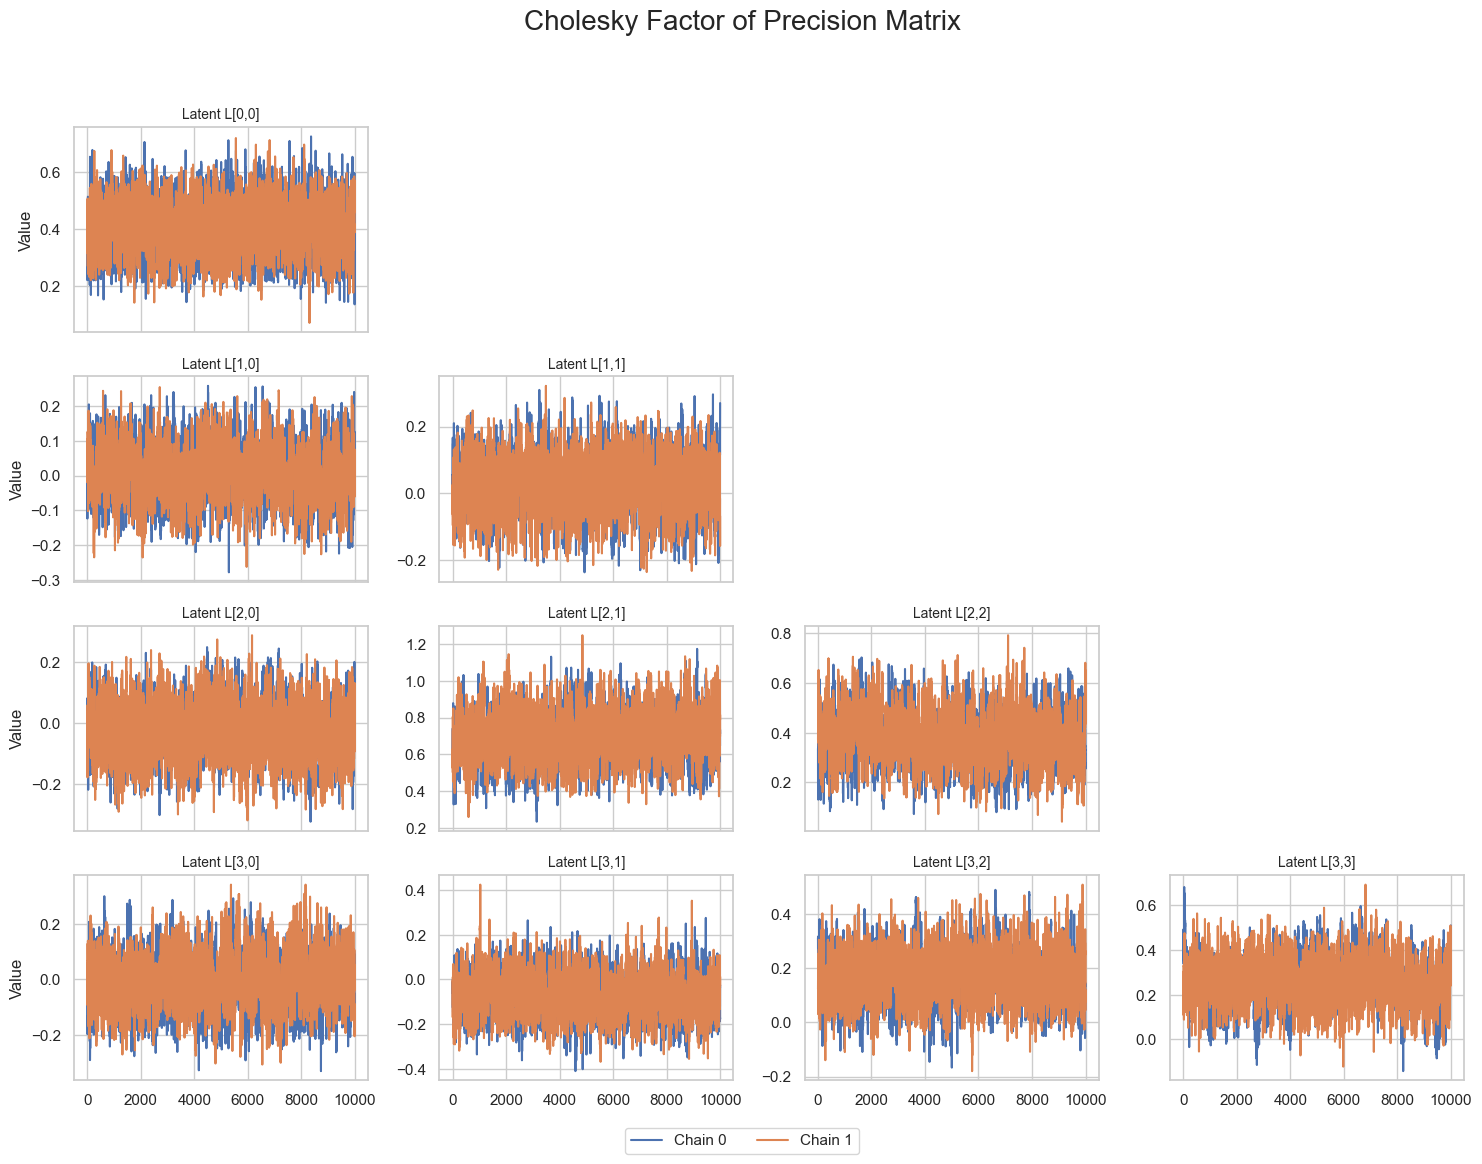

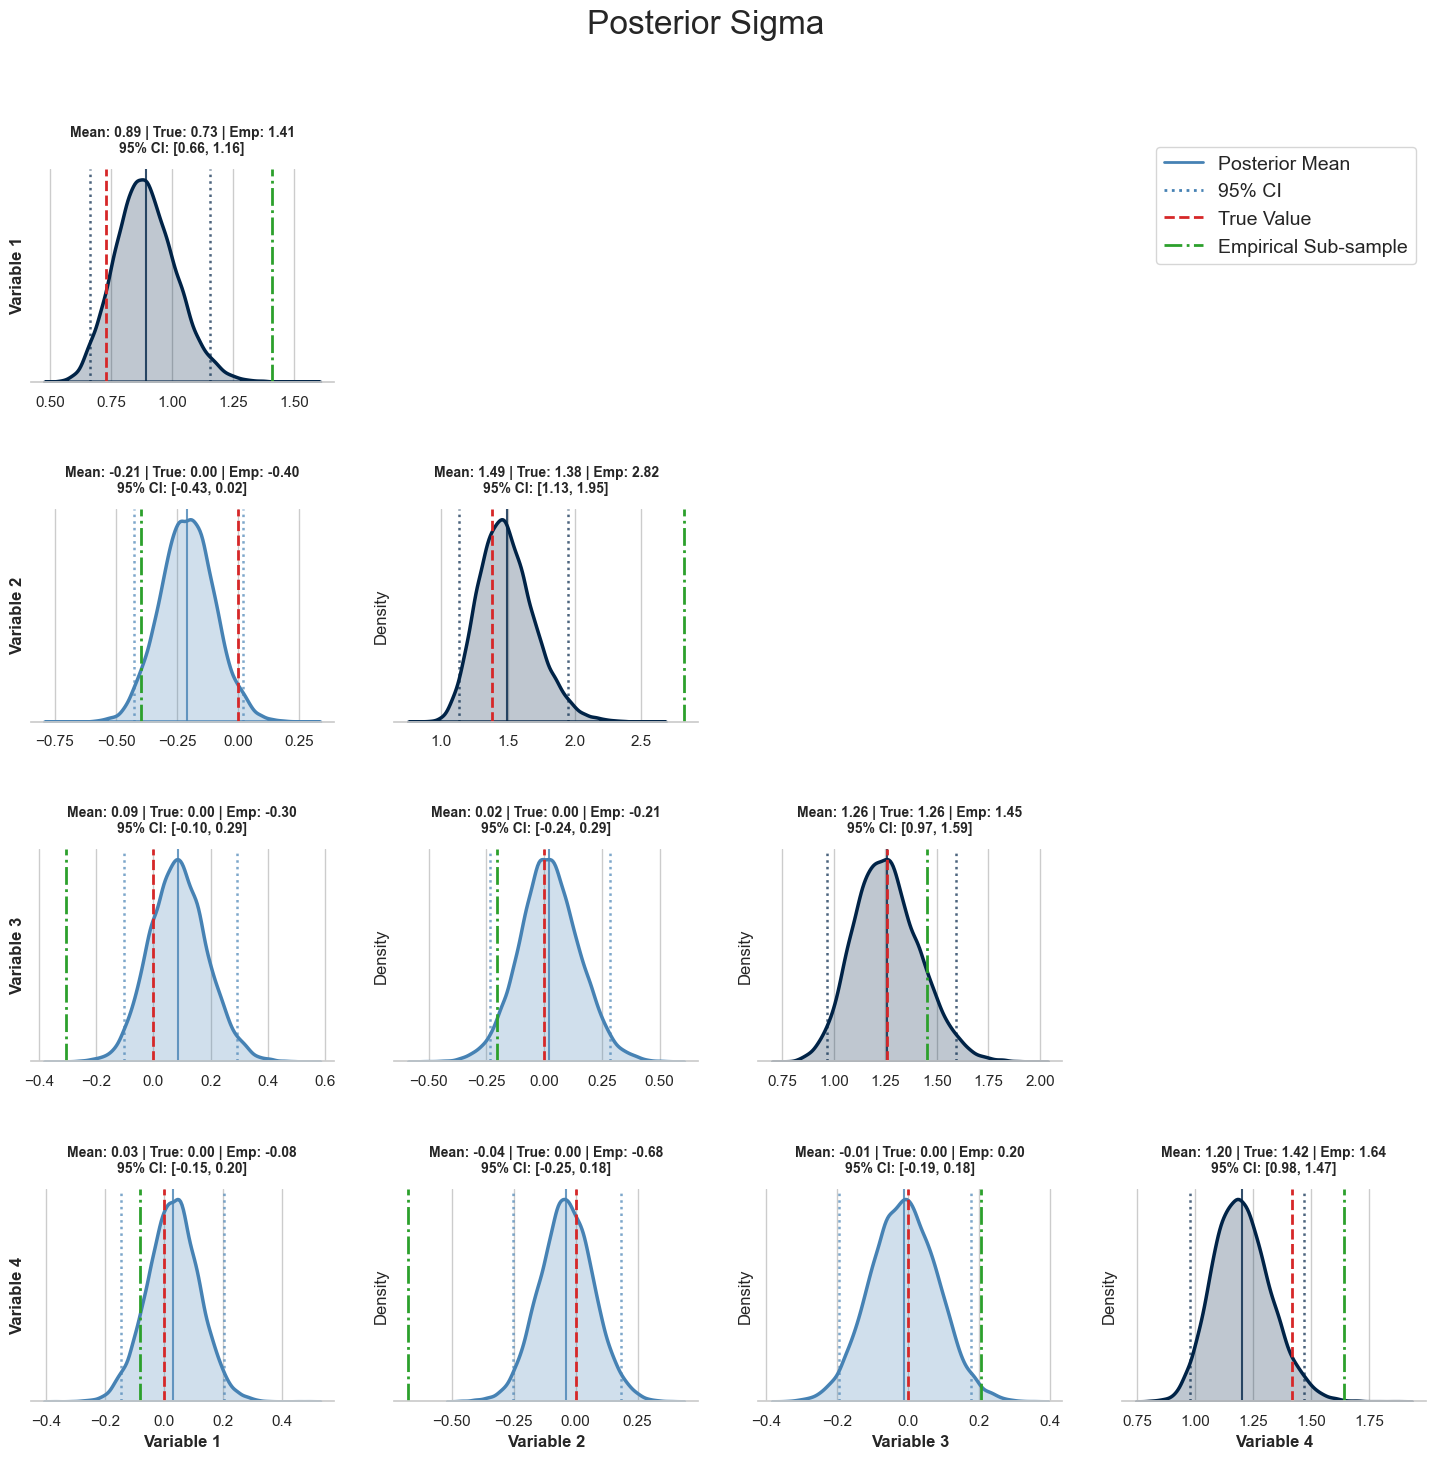

In [5]:
# ── Cell 5 : Covariance (Sigma) ──────────
# Cholesky trace first: the model stores Sigma^{-1} via its Cholesky factor,
# so this is the actual MCMC chain state used for convergence diagnosis.
plot_cholesky_trace(samples, n_params=P)

# Invert the Cholesky-of-precision draws back to Sigma for an interpretable plot.
sigma_samples = recover_covariance_matrix(samples["sigma_inv_chol_latent"])

# Empirical covariance across all true unit-level betas (no component filtering
# needed - unlike the mixture model, every unit belongs to the same component).
emp_sigma = np.cov(t_beta, rowvar=False) if t_beta is not None else None

plot_final_covariance_complete(
    samples=sigma_samples,
    true_matrix=t_sigma,
    empirical_matrix=emp_sigma,
    title="Posterior Sigma",
)

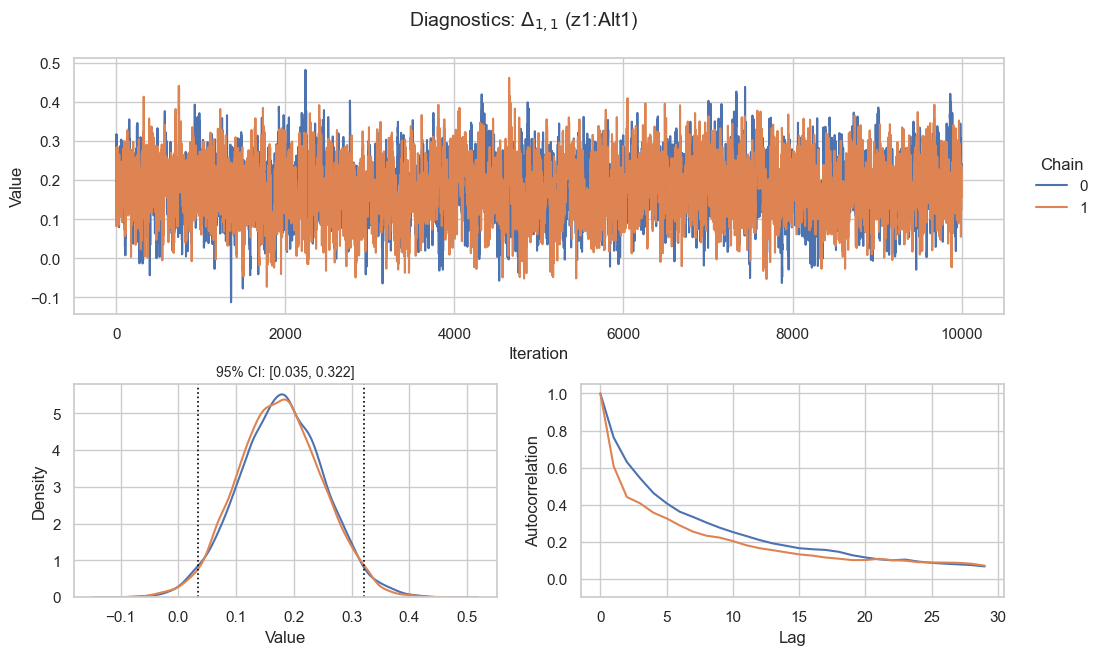

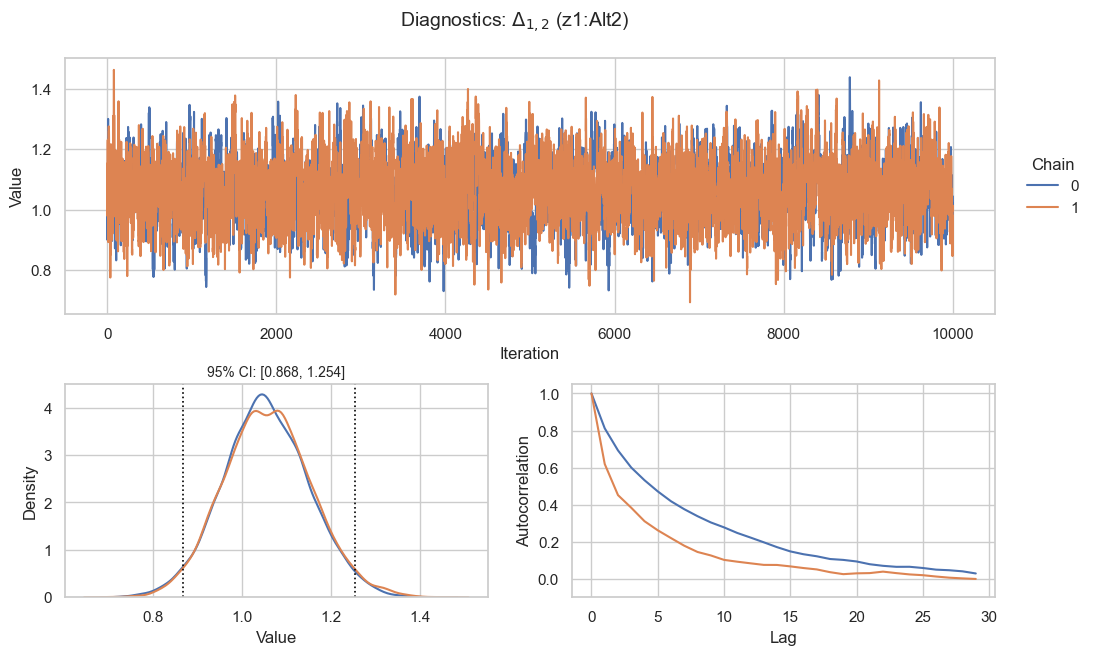

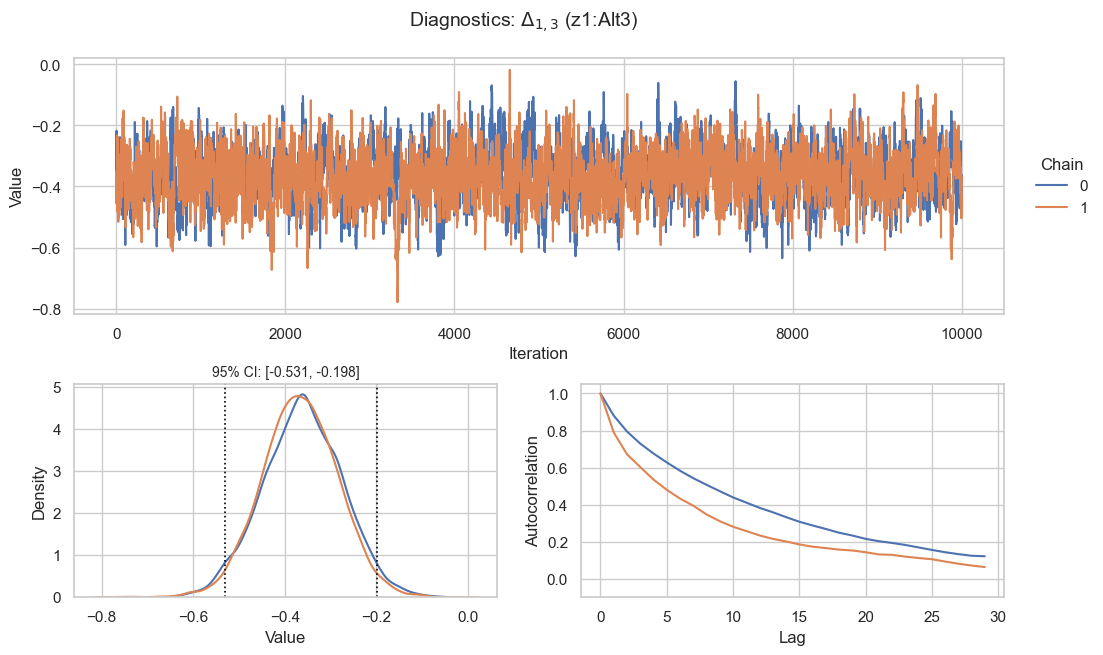

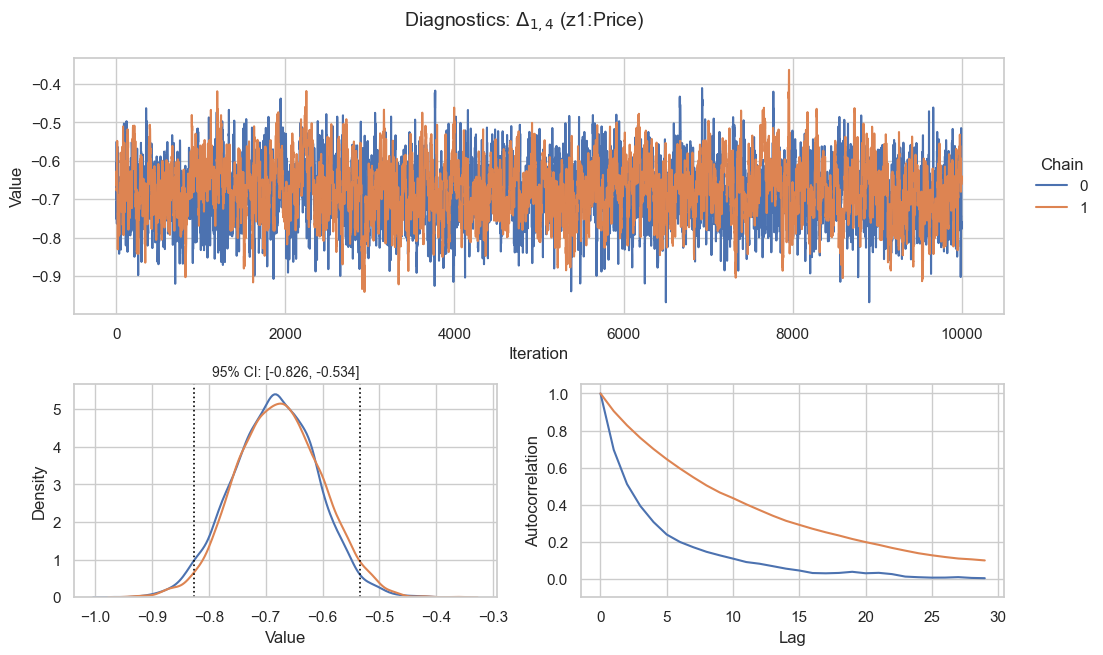

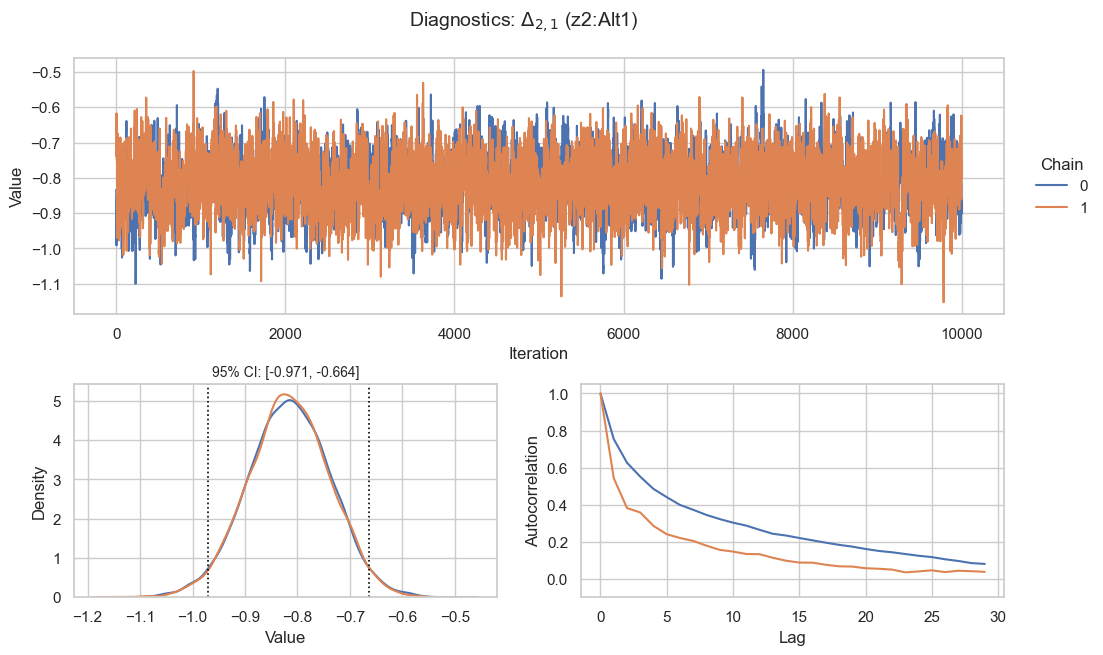

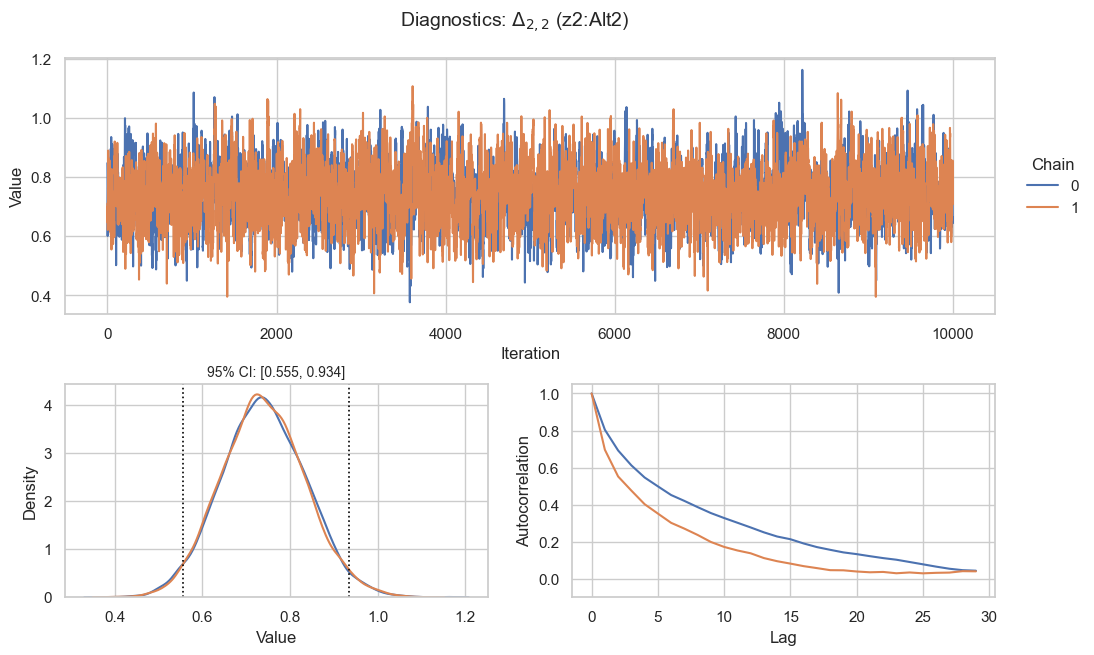

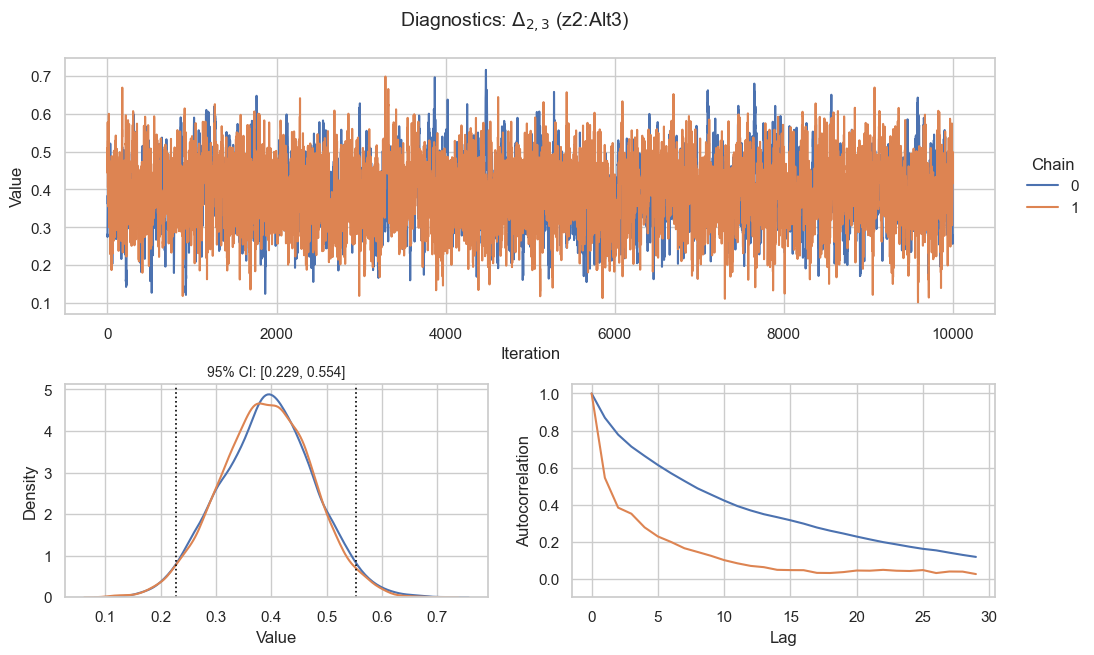

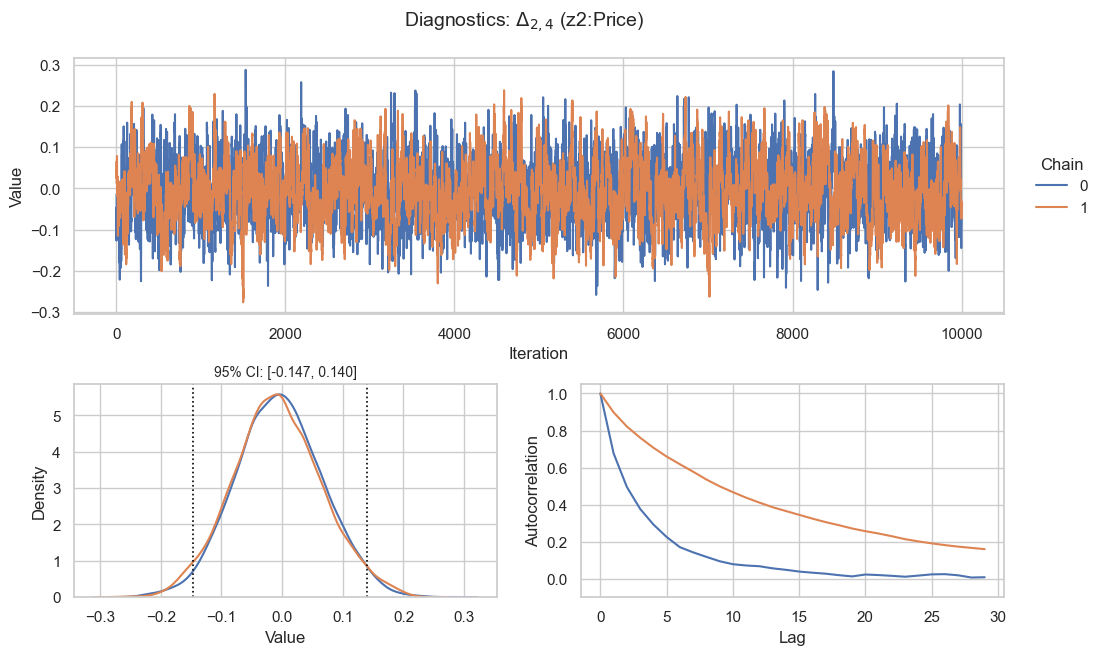


=== Posterior distribution of Delta (mean + std) ===


,Alt1,Alt2,Alt3,Price
z1,0.18 (0.07),1.06 (0.10),-0.36 (0.08),-0.68 (0.07)
z2,-0.82 (0.08),0.74 (0.10),0.39 (0.08),-0.01 (0.07)



=== Absolute Difference in Delta (|True - Posterior|) ===


,Alt1,Alt2,Alt3,Price
z1,0.029,0.119,0.023,0.058
z2,0.074,0.008,0.065,0.022


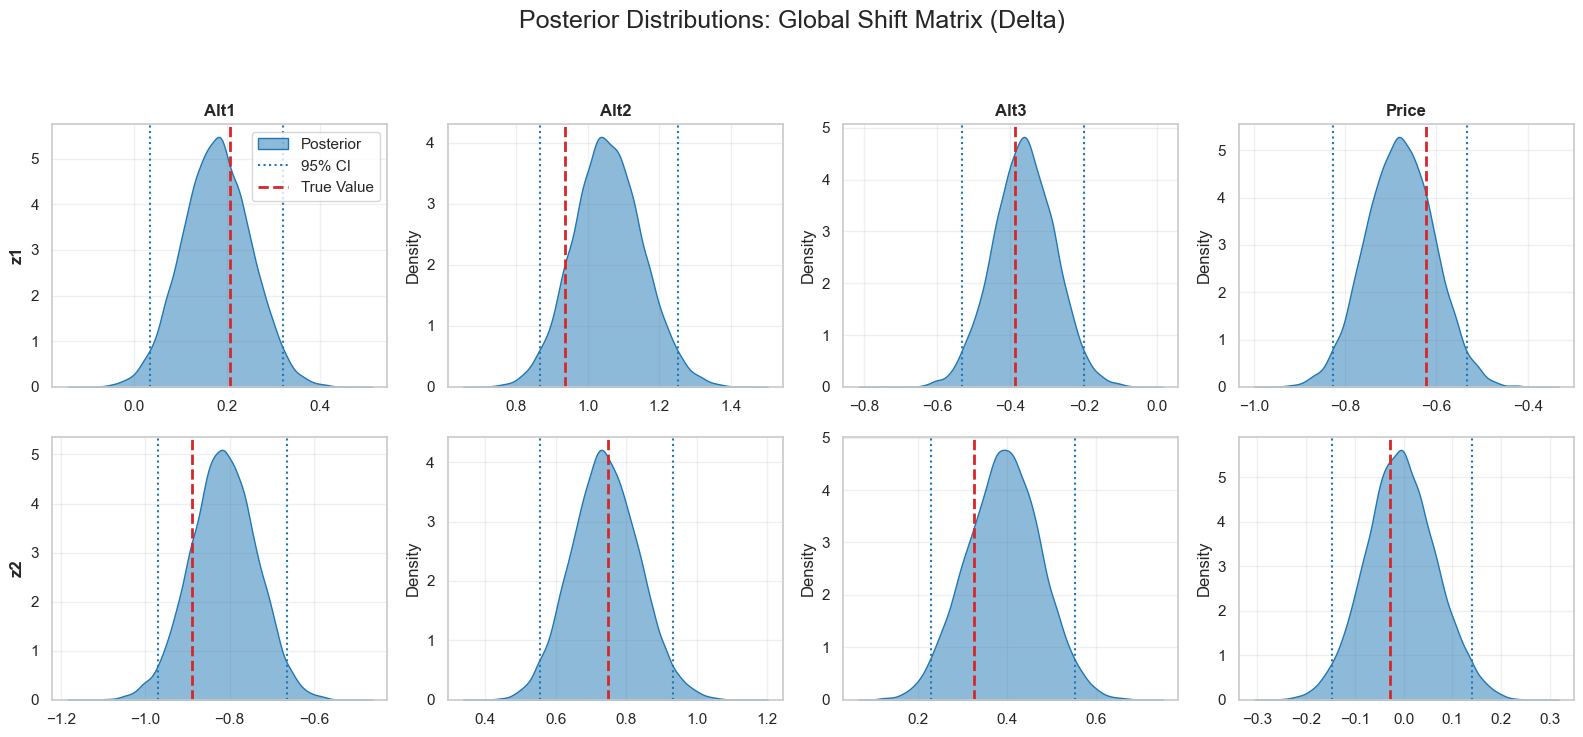

In [6]:
# ── Cell 6 : Global Shift Matrix (Delta) ──────────
# Delta is only present when the scenario includes demographic covariates (D > 0).
if D > 0 and "Delta" in samples:
    raw_delta_samples = samples["Delta"]
    # Flatten chains x draws for summary functions that expect (total_draws, D, P).
    delta_flat = raw_delta_samples.reshape(-1, D, P)

    for i in range(D):
        for j in range(P):
            plot_goose_style_diagnostics(
                raw_delta_samples, demo_idx=i, param_idx=j,
                demo_name=demo_names[i], param_name=param_names[j],
            )

    generate_delta_summaries(delta_flat, param_names, demo_names, true_delta=t_delta)
    plot_delta_distributions(delta_flat, param_names, demo_names, true_delta=t_delta)

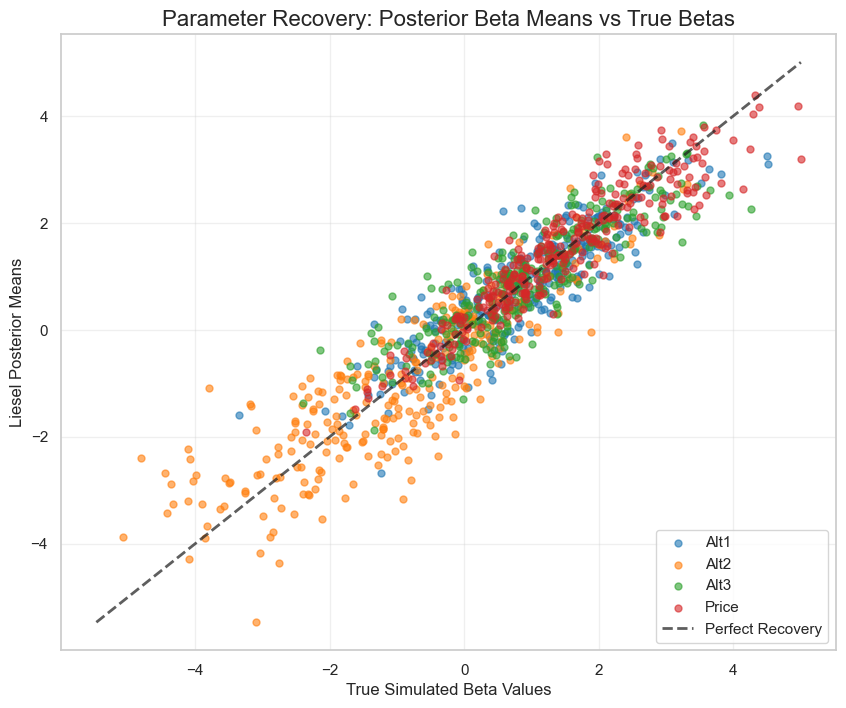

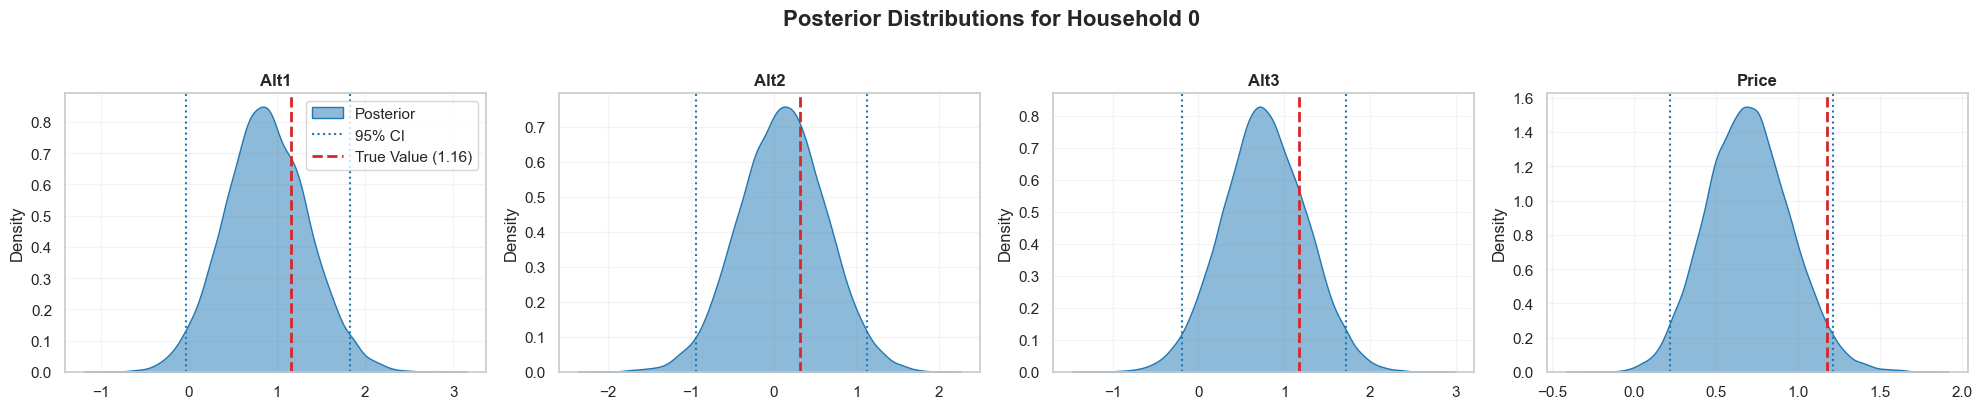

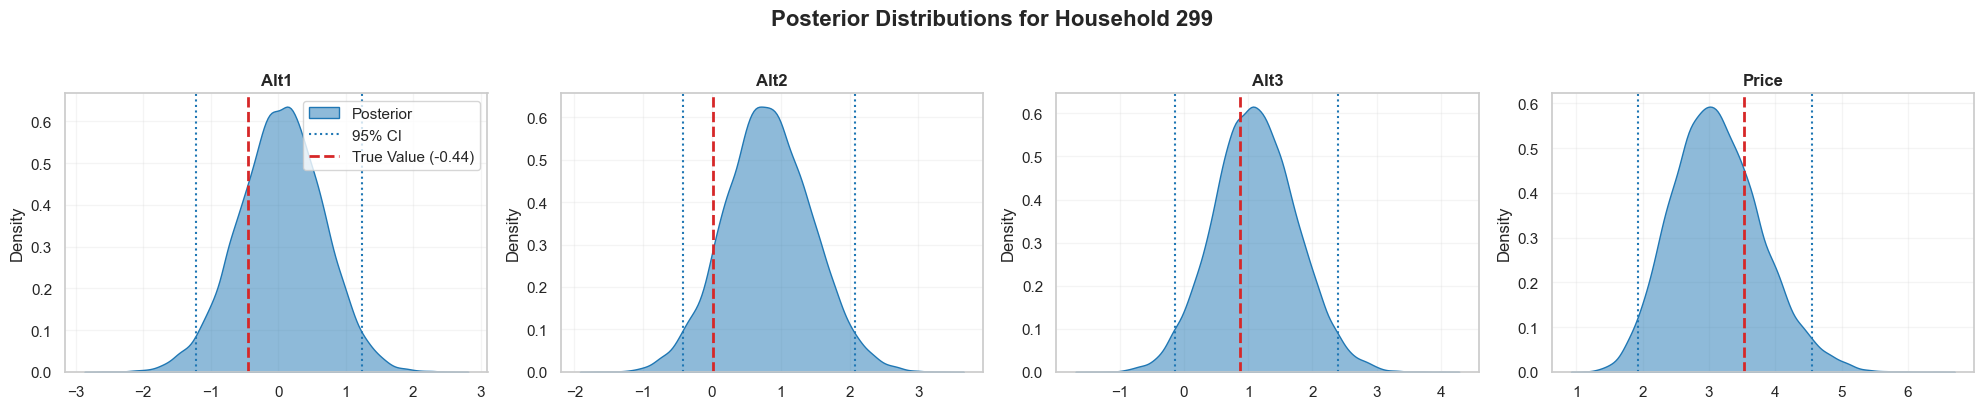

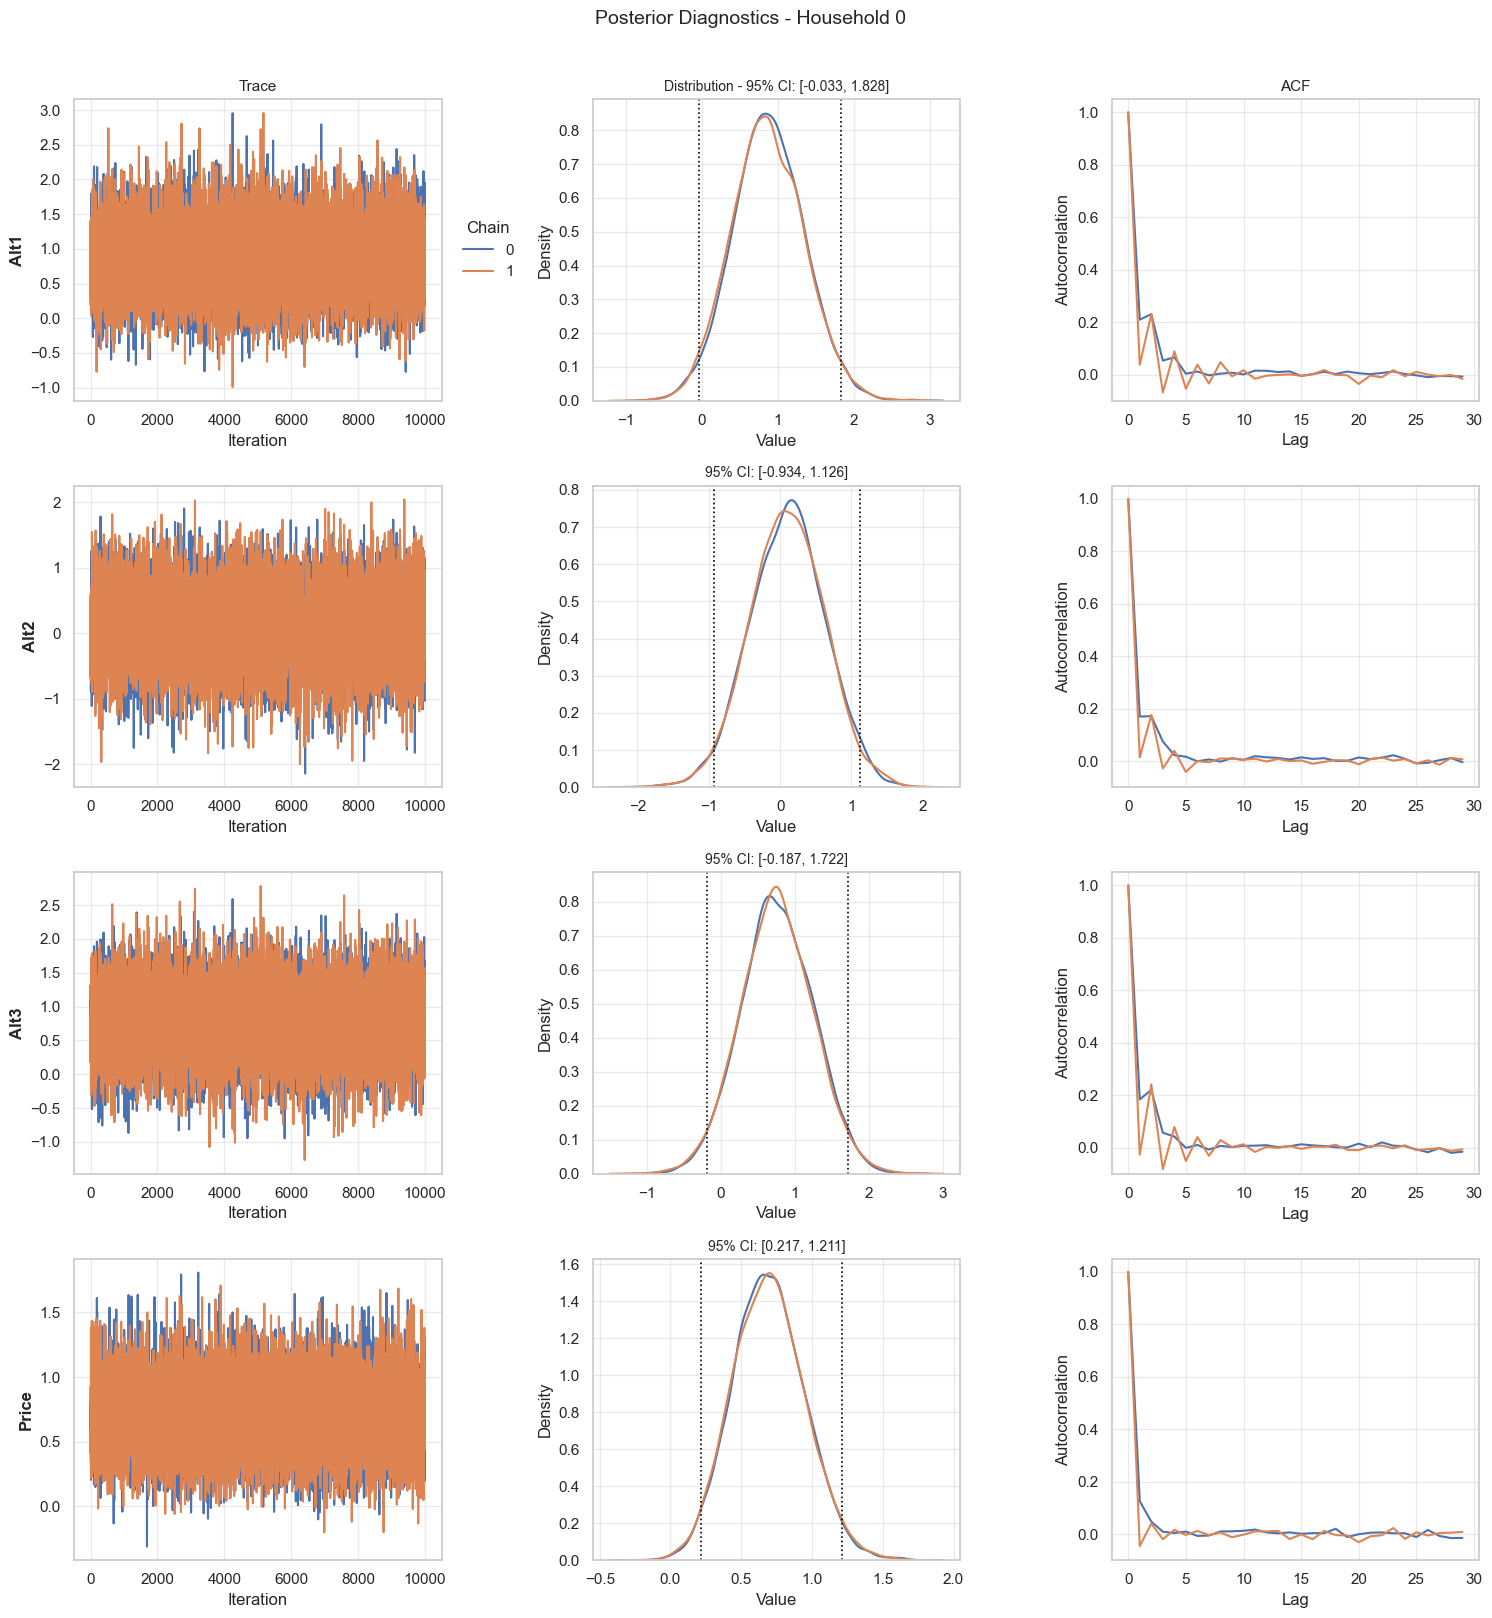

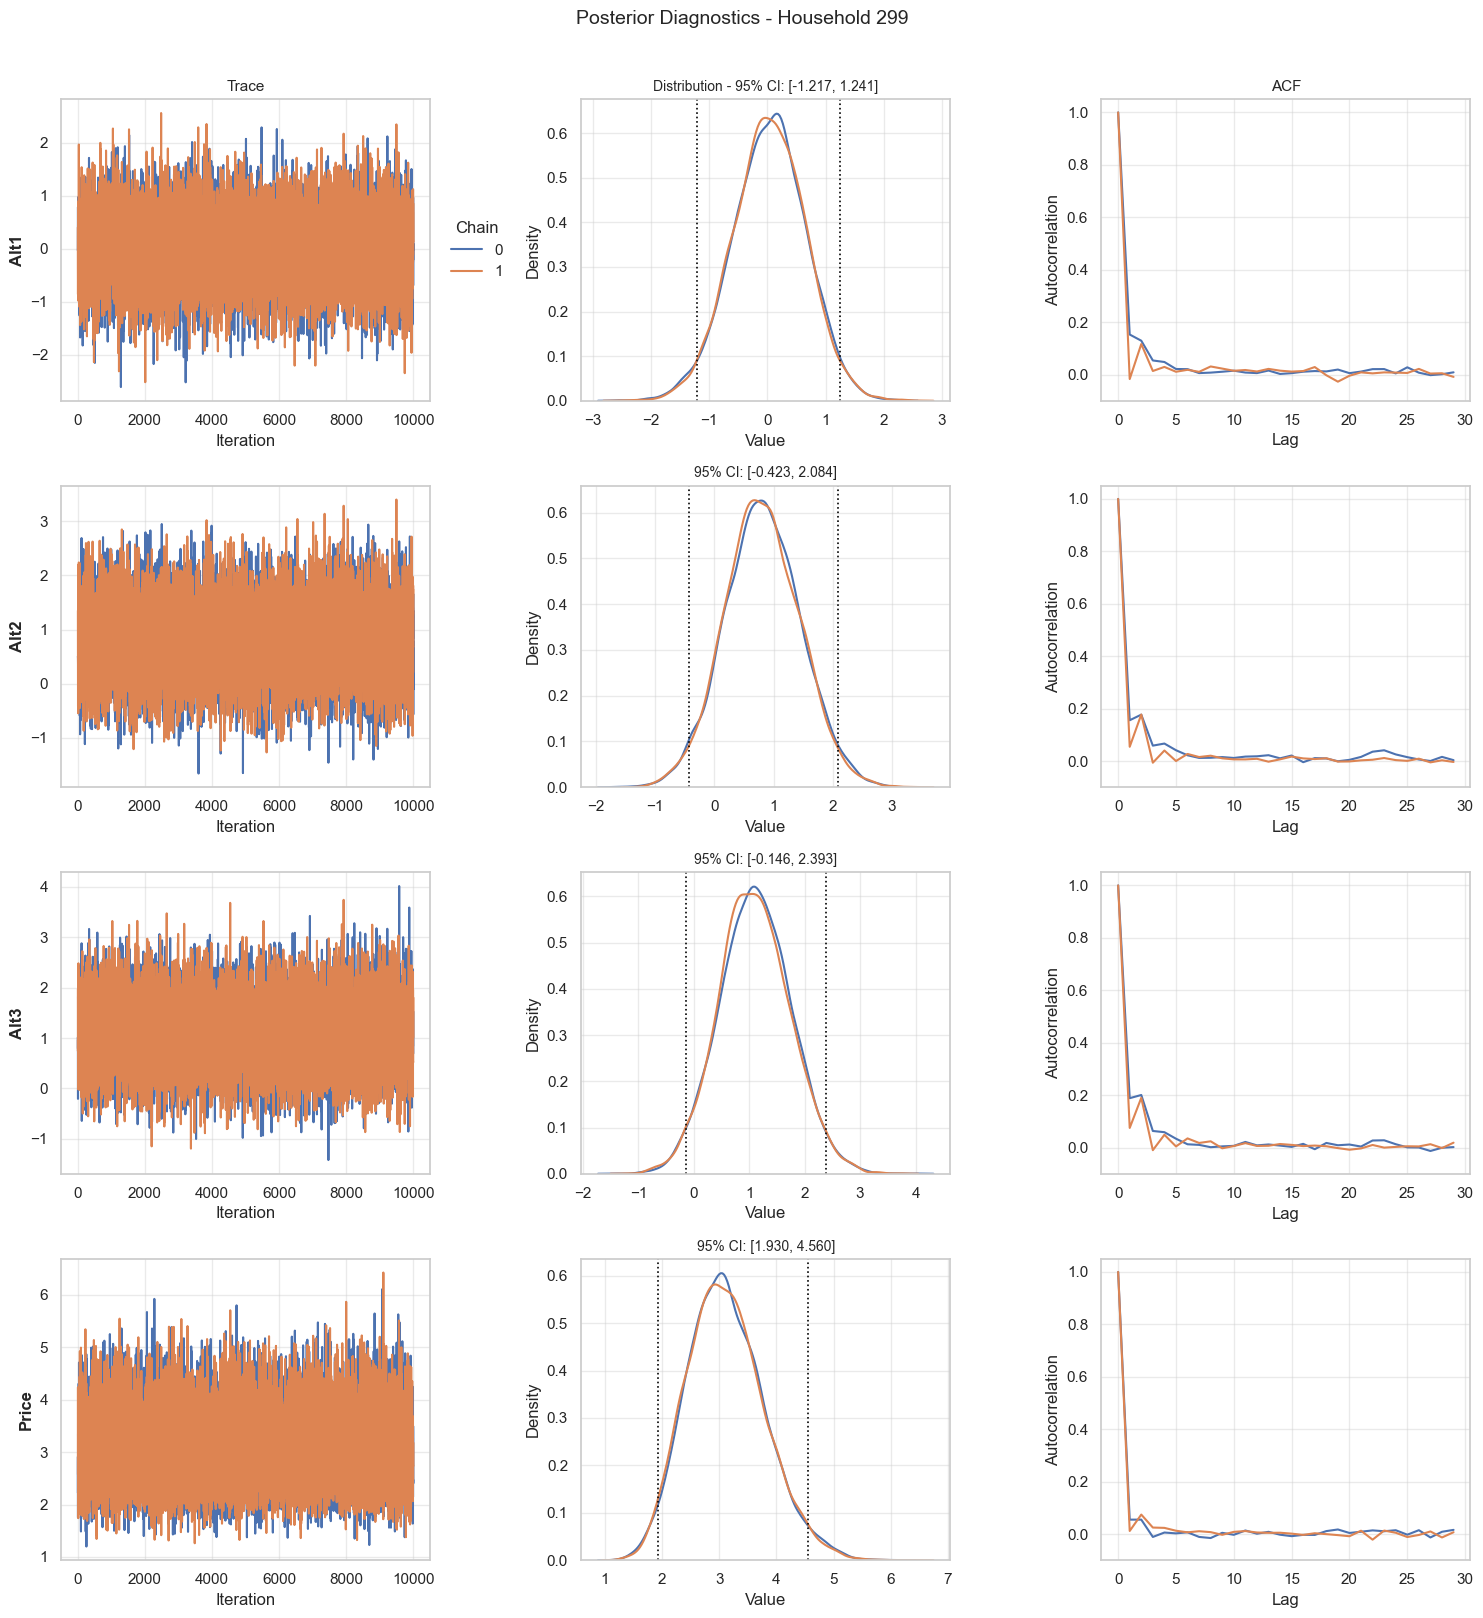

In [7]:
# ── Cell 7 : Individual-Level Betas (beta_i) ──────────
# Scatter of posterior means vs. true values across all N units and P parameters.
plot_beta_scatter(samples["beta_i"], t_beta, param_names)

# Flatten (chains, draws, N, P) -> (total_draws, N, P) for distribution plots.
liesel_beta_full = samples["beta_i"].reshape(-1, n_units, P)

# Distribution overview for two representative households.
plot_beta_distributions(
    samples=liesel_beta_full[:, 0, :],
    p_names=param_names,
    title_prefix="Posterior Distributions for Household 0",
    true_vals=t_beta[0, :] if t_beta is not None else None,
)

plot_beta_distributions(
    samples=liesel_beta_full[:, -1, :],
    p_names=param_names,
    title_prefix=f"Posterior Distributions for Household {n_units - 1}",
    true_vals=t_beta[-1, :] if t_beta is not None else None,
)

# Full MCMC diagnostics (trace, distribution, ACF) per parameter for each household.
plot_beta_unit_diagnostics(samples["beta_i"], unit_idx=0, param_names=param_names)

plot_beta_unit_diagnostics(samples["beta_i"], unit_idx=n_units - 1, param_names=param_names)

In [8]:
# ── Cell 8 : Run Artifacts ──────────
print(f"Files in {RESULTS_DIR.name}/:")
for f in sorted(RESULTS_DIR.iterdir()):
    if f.is_file():
        print(f"   {f.name:<22} {f.stat().st_size/1024:>9.1f} KB")

print("\n - posterior_raw.pkl : posterior draws as numpy arrays (mu, sigma_inv_chol_latent, Delta, beta_i)")
print(" - sampling.log      : Goose engine log (epochs + per-kernel error counts, NUTS/HMC only)")
print(" - summary.txt       : headline + per-kernel error counts (NUTS/HMC only)")
print(" - mcmc_results.pkl  : full Goose results object, needs the liesel/jax env (NUTS/HMC only)")
print(" - run.log           : R bridge subprocess log (bayesm only)")

Files in results/:
   mcmc_results.pkl        115522.5 KB
   meta.json                    5.2 KB
   posterior_raw.pkl        95469.1 KB
   sampling.log                 5.6 KB
   status.json                  0.1 KB
   summary.txt                  4.6 KB

 - posterior_raw.pkl : posterior draws as numpy arrays (mu, sigma_inv_chol_latent, Delta, beta_i)
 - sampling.log      : Goose engine log (epochs + per-kernel error counts, NUTS/HMC only)
 - summary.txt       : headline + per-kernel error counts (NUTS/HMC only)
 - mcmc_results.pkl  : full Goose results object, needs the liesel/jax env (NUTS/HMC only)
 - run.log           : R bridge subprocess log (bayesm only)
